In [1]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
import commondefs as myF
from mpl_toolkits.basemap import Basemap

plt.rcParams.update({'font.size': 10})

In [2]:
def is_feb(month):
    return month==2

def is_sep(month):
    return month==9

In [3]:
moddir = '../processed_netcdf/CMIP6_sic_1979-2014_clim/'

modnames = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_historical_r1_updated.nc').name.values
modnames = [f.strip().split('_')[0] for f in modnames]



obsdir='../processed_netcdf/OBS_sic_1979-2014_clim/'
obsnames = ['Bootstrap','NASA-Team','osisaf']
modnames = sorted(list(set(modnames)))
nobs = len(obsnames)
names = obsnames+ modnames
print(names)
nmod = len(names)
print(len(names))

['Bootstrap', 'NASA-Team', 'osisaf', 'ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'BCC-ESM1', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CESM2-WACCM-FV2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'E3SM-1-0', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM-1-2-HAM', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorCPM1', 'NorESM2-LM', 'NorESM2-MM', 'SAM0-UNICON', 'UKESM1-0-LL']
43


In [4]:
maps = [Basemap(projection='npstere', boundinglat=55, lon_0 = 0),Basemap(projection='spstere', boundinglat=-55, lon_0 = 180)]

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.
  """Entry point for launching an IPython kernel.


In [5]:
listds = []
lats = []
lons = []

for n,name in enumerate(names):
    
    if n<nobs:
        mydir = obsdir
    else:
        mydir = moddir
    ensfiles = [f for f in os.listdir(mydir) if name+'_' in f][0]
    ds = xr.open_dataset(mydir+ensfiles)
    if 'siconc' not in ds:
        if 'sic' in ds:
            ds = ds.rename({'sic':'siconc'})
        elif 'seaice' in ds:
            ds = ds.rename({'seaice':'siconc'})
        elif 'siconca' in ds:
            ds = ds.rename({'siconca':'siconc'})
            ds.siconc.values = ds.siconc.values/100.000000
        else:
            print('error for ',name,ds)
        ds.siconc.values = 100.0000*ds.siconc.values
    if 'HadGEM3-GC31-MM' in name:
        ds.siconc.values = 100.*ds.siconc.values
    print(name,np.nanmax(ds.siconc.values))
    
    
    listds.append(ds)
    lat,lon = myF.get_lats(ds)
    lats.append(lat)
    lons.append(lon)

Bootstrap 99.829994
NASA-Team 99.39
osisaf 100.0
ACCESS-CM2 99.99601
ACCESS-ESM1-5 99.97423
AWI-CM-1-1-MR 100.0
BCC-CSM2-MR 100.0
BCC-ESM1 100.0
CAMS-CSM1-0 99.99729
CESM2 99.99972
CESM2-WACCM 99.99972
CESM2-WACCM-FV2 99.99964
CNRM-CM6-1 99.4861
CNRM-CM6-1-HR 99.499916
CNRM-ESM2-1 99.49359
CanESM5 99.94076
E3SM-1-0 99.99928
EC-Earth3 99.69281
EC-Earth3-Veg 99.69207
FGOALS-f3-L 99.99968
FIO-ESM-2-0 99.99758
GFDL-CM4 99.989975
GFDL-ESM4 99.99951
GISS-E2-1-G 100.0
GISS-E2-1-G-CC 100.0
GISS-E2-1-H 100.000084
HadGEM3-GC31-LL 99.99929
HadGEM3-GC31-MM 99.999794
INM-CM4-8 98.31464
INM-CM5-0 98.39629
IPSL-CM6A-LR 99.60802
MIROC-ES2L 98.972374
MIROC6 98.95818
MPI-ESM-1-2-HAM 99.967026
MPI-ESM1-2-HR 99.78847
MPI-ESM1-2-LR 99.978676
MRI-ESM2-0 99.97471
NESM3 99.9956
NorCPM1 99.999985
NorESM2-LM 99.99974
NorESM2-MM 99.999756
SAM0-UNICON 99.9996
UKESM1-0-LL 99.99976


Bootstrap


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in less
  app.launch_new_instance()


NASA-Team
OSISAF
ACCESS-CM2
ACCESS-ESM1-5
AWI-CM-1-1-MR
BCC-CSM2-MR
BCC-ESM1
CAMS-CSM1-0
CESM2
CESM2-WACCM
CESM2-WACCM-FV2
CNRM-CM6-1
CNRM-CM6-1-HR
CNRM-ESM2-1
CanESM5
E3SM-1-0
EC-Earth3
EC-Earth3-Veg
FGOALS-f3-L
FIO-ESM-2-0
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
GISS-E2-1-G-CC
GISS-E2-1-H
HadGEM3-GC31-LL
HadGEM3-GC31-MM
INM-CM4-8
INM-CM5-0
IPSL-CM6A-LR
MIROC-ES2L
MIROC6
MPI-ESM-1-2-HAM
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NESM3
NorCPM1
NorESM2-LM
NorESM2-MM
SAM0-UNICON
UKESM1-0-LL


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


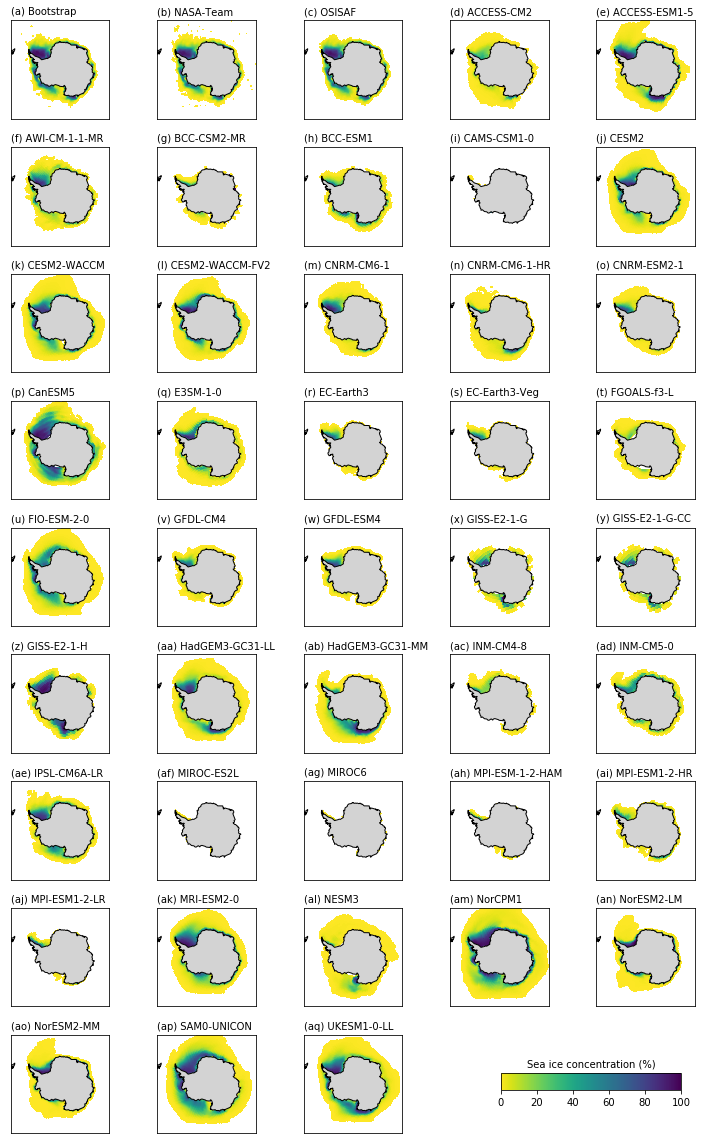

Bootstrap


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in less
  app.launch_new_instance()


NASA-Team
OSISAF
ACCESS-CM2
ACCESS-ESM1-5
AWI-CM-1-1-MR
BCC-CSM2-MR
BCC-ESM1
CAMS-CSM1-0
CESM2
CESM2-WACCM
CESM2-WACCM-FV2
CNRM-CM6-1
CNRM-CM6-1-HR
CNRM-ESM2-1
CanESM5
E3SM-1-0
EC-Earth3
EC-Earth3-Veg
FGOALS-f3-L
FIO-ESM-2-0
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
GISS-E2-1-G-CC
GISS-E2-1-H
HadGEM3-GC31-LL
HadGEM3-GC31-MM
INM-CM4-8
INM-CM5-0
IPSL-CM6A-LR
MIROC-ES2L
MIROC6
MPI-ESM-1-2-HAM
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NESM3
NorCPM1
NorESM2-LM
NorESM2-MM
SAM0-UNICON
UKESM1-0-LL


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


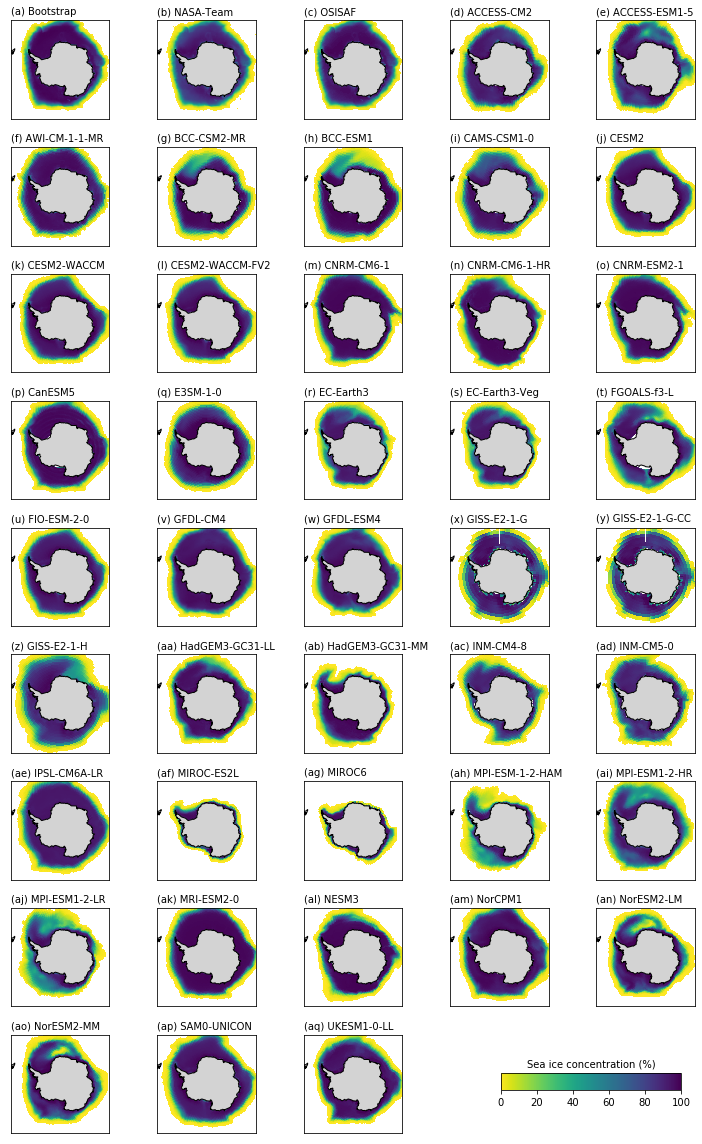

CPU times: user 6min 28s, sys: 4.88 s, total: 6min 33s
Wall time: 5min 58s


In [6]:
%%time
names[2] = 'OSISAF'
h = 1
for ct, month in enumerate([1,8]):
    fig = plt.figure(figsize=(10,16))
    for mod in range(nmod):
        print(names[mod])
        mydata = listds[mod].siconc[month,:,:]
        
        ax = plt.subplot(9,5,mod+1)
        ax.set_title(myF.alphabet[mod]+' '+names[mod],fontsize=10,loc='left')
        m = maps[h]
        x, y = m(lons[mod],lats[mod])
        
        mydata = ma.masked_where(lats[mod]>0,mydata)
        mydata = ma.masked_invalid(mydata)
        mydata = ma.masked_where(mydata<0.1,mydata)
        CS1 = m.pcolor(x,y,mydata,cmap = plt.cm.viridis_r,vmin=0.,vmax=100.)       
        m.drawcoastlines(color='black')
        m.fillcontinents(color='lightgrey')

    cbar_ax = fig.add_axes([0.7, 0.05, 0.25, 0.015]) #[left, bottom, width, height]
    cbar = fig.colorbar(CS1, cax=cbar_ax,  orientation='horizontal')
    cbar.ax.set_title(r'Sea ice concentration (%)',fontsize=10)
    plt.tight_layout()
    
    fig.savefig('figS'+str(ct+2)+'.pdf',bbox_inches='tight',dpi=300)
    plt.show()
    plt.close()